In [162]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.constants import k as k_B

In [163]:
def mean_vel(m, T):
  return np.sqrt(8 * k_B * T / (np.pi * m))

# special case where the mass of these is the same
def mean_rel_vel(m, T):
  return np.sqrt(2) * mean_vel(m, T)

In [164]:
T_0 = 273.15
T_12 = 373.15
T_eq = (T_0 + 2 * T_12) / 3
m = 1e-20

# maxwell reference value
sigma_0 = 1
# hard sphere value
sigma_t = 2/3
diameter = np.sqrt(sigma_t / np.pi)
n = 1

v_bar = mean_vel(m, T_eq)
v_rel_bar = mean_rel_vel(m, T_eq)

sigma_g_bar_maxwell = sigma_0
sigma_g_bar_hard_sphere = sigma_t * v_rel_bar

def collision_params(n, sigma_g_bar, v_bar, collision_type):
  print(f"Collision Type: {collision_type}")
  collision_frequency = n * sigma_g_bar
  mean_free_path = v_bar / collision_frequency
  mean_collision_time = 1 / collision_frequency

  print(f"Collision Frequency : {collision_frequency} Hz")
  print(f"Mean Collision Time : {mean_collision_time} s")
  print(f"Mean Free Path      : {mean_free_path} m")


  dt = 1 / 4 * mean_collision_time
  dx = 1 / 3 * mean_free_path

  print(f"Time Step Estimate  : {dt} s")
  print(f"Cell Size Estimate  : {dx} m")
  print()
  print()
  return dt, collision_frequency


dt_maxwell, collision_frequency_maxwell = collision_params(n, sigma_g_bar_maxwell, v_bar, "Maxwell")
dt_hard_sphere, collision_frequency_hard_sphere = collision_params(n, sigma_g_bar_hard_sphere, v_bar, "Hard Sphere")
print(f"Hard Sphere Diameter : {diameter}")


Collision Type: Maxwell
Collision Frequency : 1 Hz
Mean Collision Time : 1.0 s
Mean Free Path      : 1.093034918315583 m
Time Step Estimate  : 0.25 s
Cell Size Estimate  : 0.36434497277186095 m


Collision Type: Hard Sphere
Collision Frequency : 1.0305232037528436 Hz
Mean Collision Time : 0.9703808670763671 s
Mean Free Path      : 1.0606601717798214 m
Time Step Estimate  : 0.24259521676909176 s
Cell Size Estimate  : 0.3535533905932738 m


Hard Sphere Diameter : 0.46065886596178063


In [165]:
def f_M(v, T, m):
  return 4 * np.pi * v**2 * (m / (2 * np.pi * k_B * T))**(3/2) * np.exp(- m * v**2 / (2 * k_B * T))

def f_M_v(v, T, m):
  return np.sqrt((m / (2 * np.pi * k_B * T))) * np.exp(- m * v**2 / (2 * k_B * T))

# Maxwell Collision Parameters

In [166]:
maxwell_omega = 1
maxwell_alpha = 2.13986
maxwell_mu_inf_mu_1 = 1
maxwell_K_inf_K_1 = 1
maxwell_Pr = ( 2 / 3 ) * maxwell_mu_inf_mu_1 / maxwell_K_inf_K_1
maxwell_ratio = maxwell_alpha * (5 - 2 * maxwell_omega) * (7 - 2 * maxwell_omega) * maxwell_Pr / (5 * (maxwell_alpha + 1) * (maxwell_alpha + 2) * (mu_inf_mu_1))
maxwell_relaxation_rate = maxwell_ratio * collision_frequency_hard_sphere
print(maxwell_ratio)

0.32404936617788294


# Hard Sphere Collision Parameters

In [167]:
hard_sphere_omega = 0.5
hard_sphere_alpha = 1
hard_sphere_mu_inf_mu_1 = 1.016034
hard_sphere_K_inf_K_1 = 1.025218
hard_sphere_Pr = ( 2 / 3 ) * hard_sphere_mu_inf_mu_1 / hard_sphere_K_inf_K_1
hard_sphere_ratio = hard_sphere_alpha * (5 - 2 * hard_sphere_omega) * (7 - 2 * hard_sphere_omega) * hard_sphere_Pr / (5 * (hard_sphere_alpha + 1) * (hard_sphere_alpha + 2) * (mu_inf_mu_1))
hard_sphere_relaxation_rate = hard_sphere_ratio * collision_frequency_hard_sphere
print(hard_sphere_ratio)

0.5202145624963016


In [168]:
def f_analytic(v, t, T_i0, T_eq, m, relaxation_rate):
  g  = f_M_v(v, T_eq, m)
  return  g + np.exp(-relaxation_rate * t) * (f_M_v(v, T_i0, m) - g)

def T_analytic(t, T_i0, T_eq, relaxation_rate):
  return T_eq + np.exp(-relaxation_rate * t) * (T_i0 - T_eq)

In [169]:
def readData(filepath):
  data = pd.read_csv(filepath)
  components = ["x", "y", "z"]

  centers = []
  pdf = []

  for _, c in enumerate(components):
    temp_centers = ((data[f"v_{c:s}_lower"] + data[f"v_{c:s}_upper"]) / 2).to_numpy()
    counts = data[f"v_{c:s}"]
    total = np.trapezoid(counts, temp_centers)
    centers.append(temp_centers)
    pdf.append(counts / total)
  return data, pdf, centers

In [170]:
def compareToAnswer(filepath, t, T_0s, T_eq, m, relaxation_rate):
    data, pdf, centers = readData(filepath)
    for i, (T_i0, center) in enumerate(zip(T_0s, centers)):
      expected_f = f_analytic(center, t, T_i0, T_eq, m, relaxation_rate)
      plt.figure()
      plt.plot(centers[i], pdf[i], label='Simulated')
      plt.plot(centers[i], expected_f, label='Actual')
      plt.show()

In [203]:
T_0s = [T_0, T_12, T_12]
print("Hard Sphere Compare")
time_step = 100
# compareToAnswer(f"testing_csv_distribution_0600.csv", 100 * dt_hard_sphere, T_0s, T_eq, m, hard_sphere_relaxation_rate)
# print("Maxwell Compare")
compareToAnswer(f"testing_csv_distribution_{time_step:04}.csv", time_step * dt_maxwell, T_0s, T_eq, m, maxwell_alpha)

Hard Sphere Compare


FileNotFoundError: [Errno 2] No such file or directory: 'testing_csv_distribution_0100.csv'

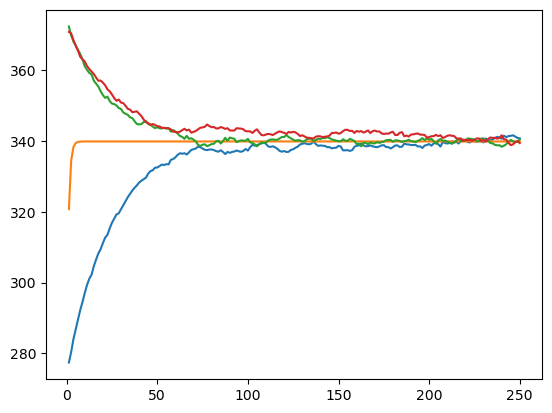

In [202]:
m = 1e-20
M = m + m
m_ab = m * m / (M )
n = 1
sigma_0 = 1
nu_ab = m_ab / M * 3 * n * sigma_0

data = pd.read_csv("testing_csv.csv")
time = data["time"]
plt.figure()
plt.plot(time, data["T_x"])
plt.plot(time, T_analytic(time, T_0, T_eq, 4/3 * nu_ab * collision_frequency_maxwell ))
plt.plot(time, data["T_y"])
plt.plot(time, data["T_z"])
plt.show()